# importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reading file

In [2]:
df=pd.read_csv("E:/ecommerce_dataset.csv")

In [3]:
df

,date,product_id,quantity,price,customer_id,category
0,2023-01-01,52,34,87.79,424,Books
1,2023-01-02,93,47,402.95,142,Sports
2,2023-01-03,15,8,141.39,291,Books
3,2023-01-04,72,40,571.87,432,Sports
4,2023-01-05,61,49,692.57,749,Clothing
...,...,...,...,...,...,...
995,2025-09-22,10,41,148.62,978,Home
996,2025-09-23,67,13,284.05,154,Books
997,2025-09-24,18,30,971.82,390,Sports
998,2025-09-25,100,33,338.03,260,Clothing


In [4]:
df.head()

,date,product_id,quantity,price,customer_id,category
0,2023-01-01,52,34,87.79,424,Books
1,2023-01-02,93,47,402.95,142,Sports
2,2023-01-03,15,8,141.39,291,Books
3,2023-01-04,72,40,571.87,432,Sports
4,2023-01-05,61,49,692.57,749,Clothing


In [5]:
df.tail()

,date,product_id,quantity,price,customer_id,category
995,2025-09-22,10,41,148.62,978,Home
996,2025-09-23,67,13,284.05,154,Books
997,2025-09-24,18,30,971.82,390,Sports
998,2025-09-25,100,33,338.03,260,Clothing
999,2025-09-26,86,13,487.22,620,Sports


In [6]:
df.shape

(1000, 6)

In [7]:
df.isnull().sum()

date           0
product_id     0
quantity       0
price          0
customer_id    0
category       0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1000 non-null   object 
 1   product_id   1000 non-null   int64  
 2   quantity     1000 non-null   int64  
 3   price        1000 non-null   float64
 4   customer_id  1000 non-null   int64  
 5   category     1000 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


In [9]:
df.describe()

,product_id,quantity,price,customer_id
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.128000,25.682000,509.643610,506.171000
std,29.573505,14.203401,285.145454,285.939685
min,1.000000,1.000000,13.190000,1.000000
25%,24.000000,13.000000,255.862500,263.750000
50%,51.000000,26.000000,522.185000,518.500000
75%,75.000000,37.250000,750.777500,749.000000
max,100.000000,50.000000,999.420000,999.000000


# Convert date column to datetime format

In [10]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

# Create revenue column

In [11]:
df['revenue'] = df['quantity'] * df['price']

In [12]:
df

,date,product_id,quantity,price,customer_id,category,month,revenue
0,2023-01-01,52,34,87.79,424,Books,2023-01,2984.86
1,2023-01-02,93,47,402.95,142,Sports,2023-01,18938.65
2,2023-01-03,15,8,141.39,291,Books,2023-01,1131.12
3,2023-01-04,72,40,571.87,432,Sports,2023-01,22874.80
4,2023-01-05,61,49,692.57,749,Clothing,2023-01,33935.93
...,...,...,...,...,...,...,...,...
995,2025-09-22,10,41,148.62,978,Home,2025-09,6093.42
996,2025-09-23,67,13,284.05,154,Books,2025-09,3692.65
997,2025-09-24,18,30,971.82,390,Sports,2025-09,29154.60
998,2025-09-25,100,33,338.03,260,Clothing,2025-09,11154.99


# Sales trend over time

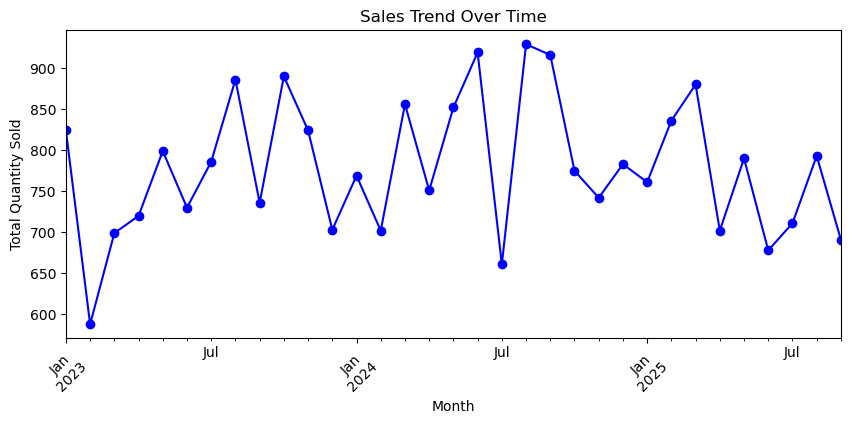

In [13]:
monthly_sales = df.groupby('month')['quantity'].sum()
plt.figure(figsize=(10, 4))
monthly_sales.plot(marker='o', color='b', linestyle='-')
plt.title("Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

# Revenue by category

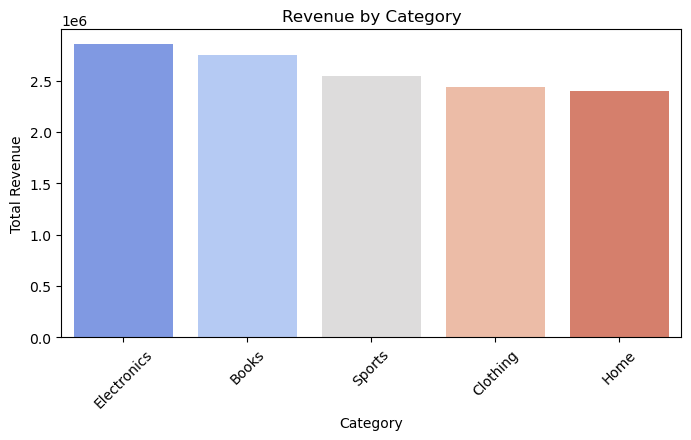

In [14]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='coolwarm')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

# Top-selling products

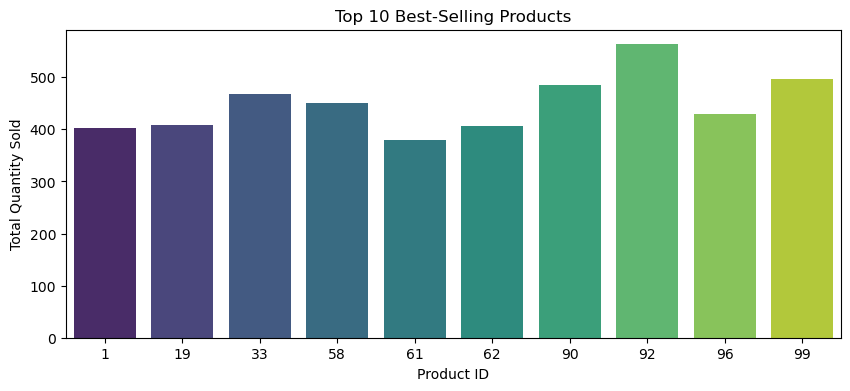

In [15]:

top_products = df.groupby('product_id')['quantity'].sum().nlargest(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Total Quantity Sold")
plt.show()

# Customer spending analysis

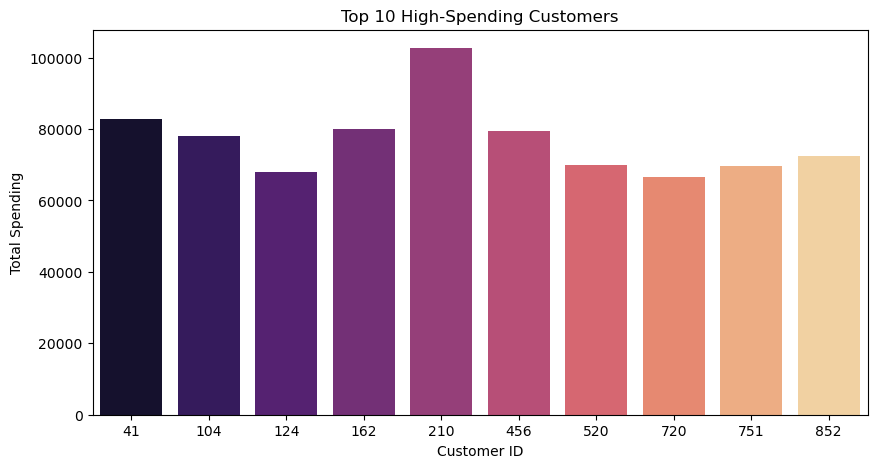

In [16]:
customer_spending = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=customer_spending.head(10).index, y=customer_spending.head(10).values, palette='magma')
plt.title("Top 10 High-Spending Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

# Quantity distribution

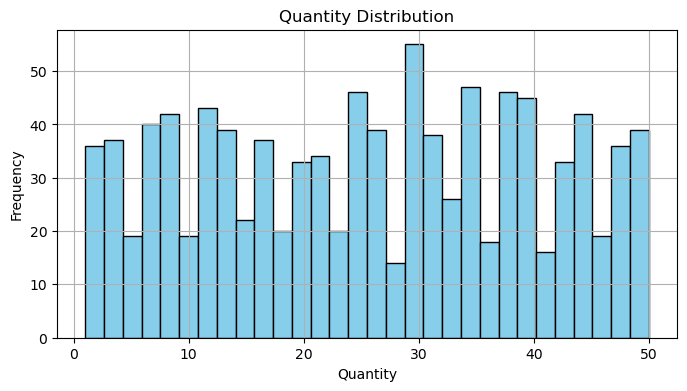

In [17]:
df['quantity'].hist(bins=30, color='skyblue', edgecolor='black', figsize=(8, 4))
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# Price distribution

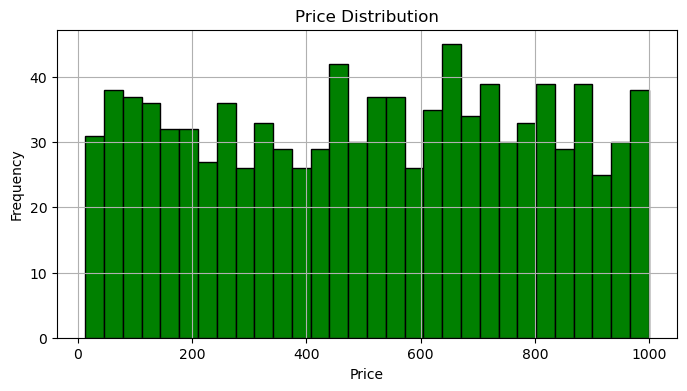

In [18]:
df['price'].hist(bins=30, color='green', edgecolor='black', figsize=(8, 4))
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Sales forecasting (simple linear regression)

In [19]:
df['date_ordinal'] = df['date'].map(pd.Timestamp.toordinal)
X = df[['date_ordinal']]
y = df['quantity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")

MAE: 12.04, MSE: 191.88, RMSE: 13.85
